<a href="https://colab.research.google.com/github/MateoGlz/Progra-Analitica-Descriptica-Predictiva/blob/main/Entrega_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

path_stress = kagglehub.dataset_download("aksahaha/crop-recommendation")
print("📂 Path del dataset:", path_stress)

print("\n📁 Archivos encontrados:")
for root, dirs, files in os.walk(path_stress):
    for file in files:
        full_path = os.path.join(root, file)
        print(f"  - {file} (Tamaño: {os.path.getsize(full_path)} bytes)")

print("\n📄 Archivos en directorio principal:")
all_files = os.listdir(path_stress)
for file in all_files:
    file_path = os.path.join(path_stress, file)
    if os.path.isfile(file_path):
        print(f"  - {file}")




csv_path = os.path.join(path_stress, 'Crop_recommendation.csv')

df = pd.read_csv(csv_path)
df = df.dropna(axis=1, how='all')


df = df.rename(columns={'label': 'cultivo'})
df.head(100)


100%|██████████| 62.6k/62.6k [00:00<00:00, 8.32MB/s]

Extracting files...
📂 Path del dataset: /root/.cache/kagglehub/datasets/aksahaha/crop-recommendation/versions/1

📁 Archivos encontrados:
  - Crop_recommendation.csv (Tamaño: 149263 bytes)

📄 Archivos en directorio principal:
  - Crop_recommendation.csv


,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,cultivo
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
95,88,46,42,22.683191,83.463583,6.604993,194.265172,rice
96,93,47,37,21.533463,82.140041,6.500343,295.924880,rice
97,60,55,45,21.408658,83.329319,5.935745,287.576693,rice
98,78,35,44,26.543481,84.673536,7.072656,183.622266,rice


=== CONFIGURACION GRIDSEARCHCV - CLASIFICACION DE CULTIVOS ===
Dataset: 2200 registros
Target: cultivo
Dimensiones: X (2200, 7), y (2200,)
Numero de clases: 22
Distribucion de clases:
cultivo
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
Name: count, dtype: int64

EJECUTANDO GRID SEARCH
Fitting 5 folds for each of 70 candidates, totalling 350 fits

RESULTADOS GRID SEARCH:
Mejores parametros: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 15}
Mejor accuracy: 0.9882


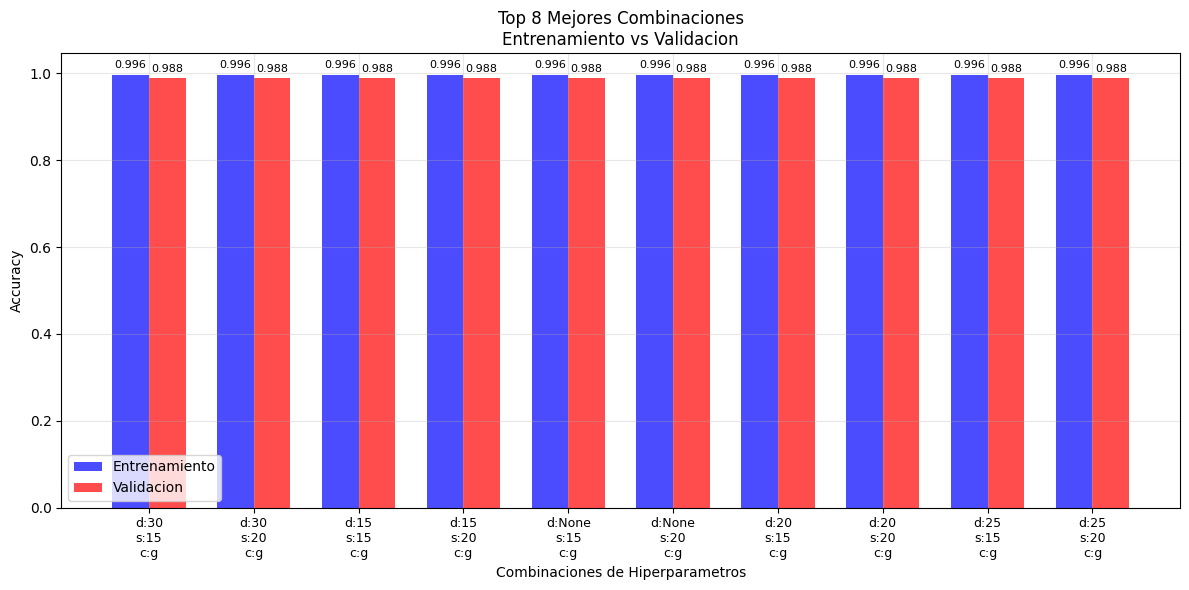

In [ ]:

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIGURACION PARA GRIDSEARCHCV
print("=== CONFIGURACION GRIDSEARCHCV - CLASIFICACION DE CULTIVOS ===")
print("Dataset: 2200 registros")
print("Target: cultivo")

# Preparar datos
X = df.drop('cultivo', axis=1)
y = df['cultivo']

print(f"Dimensiones: X {X.shape}, y {y.shape}")
print(f"Numero de clases: {len(y.unique())}")
print(f"Distribucion de clases:\n{y.value_counts().head()}")

# DEFINIR EL ESPACIO DE BUSQUEDA
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15, 20]
}

# CONFIGURAR STRATIFIED KFOLD
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CONFIGURAR Y EJECUTAR GRID SEARCH
print(f"\nEJECUTANDO GRID SEARCH")
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X, y)

# RESULTADOS PRINCIPALES
print(f"\nRESULTADOS GRID SEARCH:")
print(f"Mejores parametros: {grid_search.best_params_}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

# GRAFICA 1: TOP 8 MEJORES COMBINACIONES (ENTRENAMIENTO VS VALIDACION)
plt.figure(figsize=(12, 6))

# Obtener top 5 combinaciones
top_8_indices = np.argsort(grid_search.cv_results_['mean_test_score'])[-10:]
top_8_train_scores = [grid_search.cv_results_['mean_train_score'][i] for i in top_8_indices]
top_8_test_scores = [grid_search.cv_results_['mean_test_score'][i] for i in top_8_indices]
top_8_params = [f"d:{grid_search.cv_results_['params'][i]['max_depth']}\n"
               f"s:{grid_search.cv_results_['params'][i]['min_samples_split']}\n"
               f"c:{grid_search.cv_results_['params'][i]['criterion'][0]}"
               for i in top_8_indices]

x_pos = np.arange(len(top_8_params))
bar_width = 0.35

plt.bar(x_pos - bar_width/2, top_8_train_scores, bar_width, label='Entrenamiento', alpha=0.7, color='blue')
plt.bar(x_pos + bar_width/2, top_8_test_scores, bar_width, label='Validacion', alpha=0.7, color='red')

plt.xlabel('Combinaciones de Hiperparametros')
plt.ylabel('Accuracy')
plt.title('Top 8 Mejores Combinaciones\nEntrenamiento vs Validacion')
plt.xticks(x_pos, top_8_params, fontsize=9)
plt.legend()
plt.grid(True, alpha=0.3)

for i, (train_score, test_score) in enumerate(zip(top_8_train_scores, top_8_test_scores)):
    plt.text(i - bar_width/2, train_score + 0.01, f'{train_score:.3f}', ha='center', va='bottom', fontsize=8)
    plt.text(i + bar_width/2, test_score + 0.01, f'{test_score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()




ENTRENANDO MEJOR MODELO PARA ANALISIS DETALLADO
Mostrando todas las clases 22


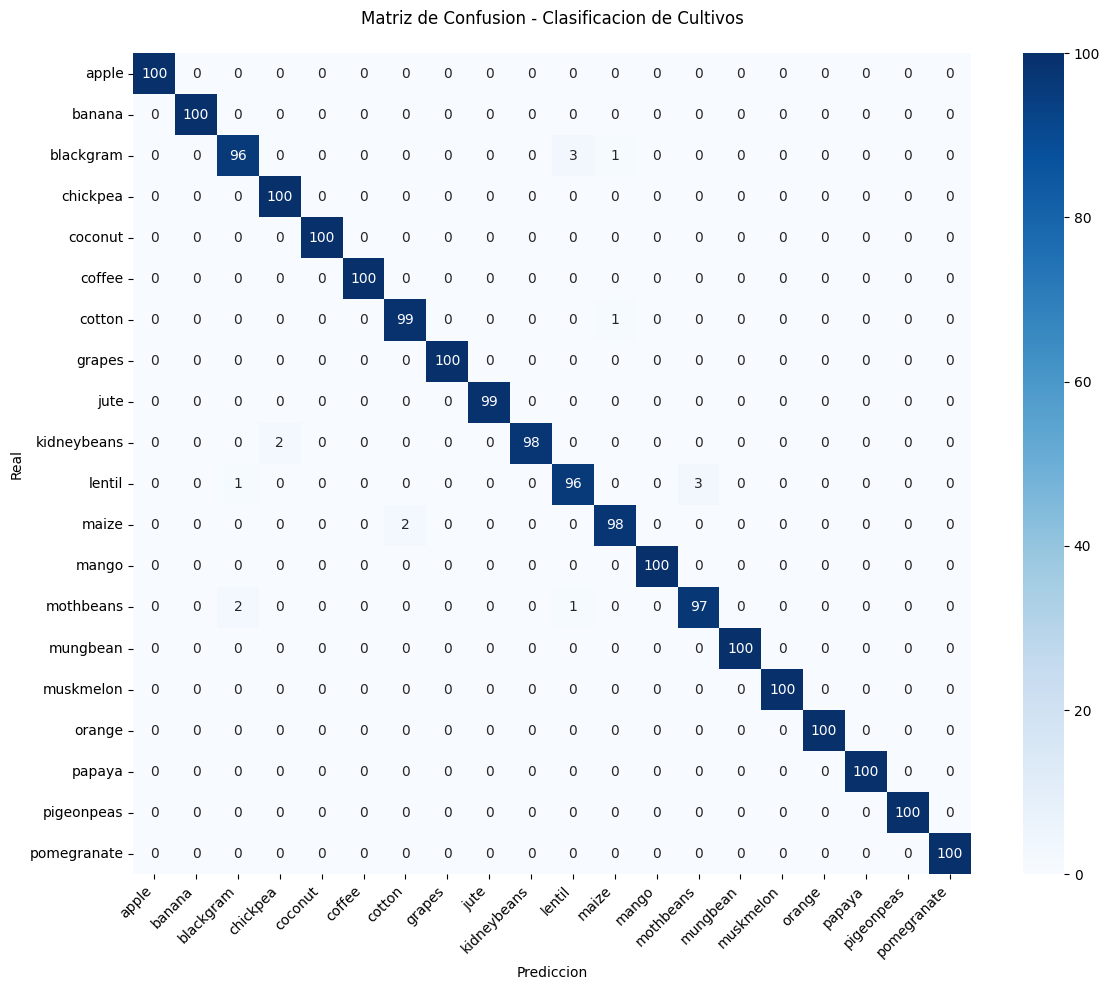

In [ ]:
# ENTRENAR MEJOR MODELO PARA ANALISIS DETALLADO
print(f"\nENTRENANDO MEJOR MODELO PARA ANALISIS DETALLADO")
best_model = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)

# Usar Stratified K-Fold para obtener predicciones consistentes
y_true = []
y_pred = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    best_model.fit(X_train, y_train)
    fold_pred = best_model.predict(X_test)

    y_true.extend(y_test)
    y_pred.extend(fold_pred)

# GRAFICA 2: MATRIZ DE CONFUSION
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)

# Mostrar solo las primeras 15 clases para mejor visualizacion
classes = sorted(y.unique())
if len(classes) > 20:
    print(f"Mostrando todas las clases {len(classes)}")
    classes_to_show = classes[:20]
    # Filtrar matriz de confusion para las primeras 15 clases
    cm_small = cm[:20, :20]
else:
    classes_to_show = classes
    cm_small = cm

sns.heatmap(cm_small, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_to_show,
            yticklabels=classes_to_show)
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de Confusion - Clasificacion de Cultivos\n')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



In [ ]:
# GRAFICA 3: PRECISION POR CULTIVO (CORREGIDO)
print(f"\nCALCULANDO PRECISION POR CULTIVO")
from sklearn.metrics import precision_score

# Calcular precision por clase
precision_por_clase = precision_score(y_true, y_pred, average=None, labels=classes)

# ANALISIS DETALLADO POR CLASE (CORREGIDO)
print(f"\nANALISIS DETALLADO POR CLASE:")
print("="*50)

# REPORTE DE CLASIFICACION COMPLETO (CORREGIDO)
print(f"\nREPORTE DE CLASIFICACION:")
print("="*50)

# CORRECION: Usar todas las clases en target_names
print(classification_report(y_true, y_pred, target_names=[str(c) for c in classes], digits=3))

# RESUMEN FINAL
print(f"\nRESUMEN FINAL:")
print(f"Mejor configuracion: {grid_search.best_params_}")
print(f"Accuracy general: {accuracy_score(y_true, y_pred):.4f}")
print(f"Numero de clases: {len(classes)}")
print(f"Rango de precision por clase: {min(precision_por_clase):.3f} - {max(precision_por_clase):.3f}")


CALCULANDO PRECISION POR CULTIVO

ANALISIS DETALLADO POR CLASE:

REPORTE DE CLASIFICACION:
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000       100
      banana      1.000     1.000     1.000       100
   blackgram      0.970     0.960     0.965       100
    chickpea      0.980     1.000     0.990       100
     coconut      1.000     1.000     1.000       100
      coffee      1.000     1.000     1.000       100
      cotton      0.980     0.990     0.985       100
      grapes      1.000     1.000     1.000       100
        jute      0.917     0.990     0.952       100
 kidneybeans      1.000     0.980     0.990       100
      lentil      0.960     0.960     0.960       100
       maize      0.980     0.980     0.980       100
       mango      1.000     1.000     1.000       100
   mothbeans      0.970     0.970     0.970       100
    mungbean      1.000     1.000     1.000       100
   muskmelon      1.000     1.000     1.000

MODELO GUARDADO: modelo_clasificacion_cultivos.pkl

PRUEBA DEL MODELO CON DATOS DE EJEMPLO

ANALISIS DE IMPORTANCIA DE VARIABLES

IMPORTANCIA DE CADA VARIABLE:
Caracteristica  Importancia
      rainfall     0.273514
      humidity     0.220805
    phosphorus     0.208622
      Nitrogen     0.140841
     potassium     0.093595
   temperature     0.052849
            ph     0.009774


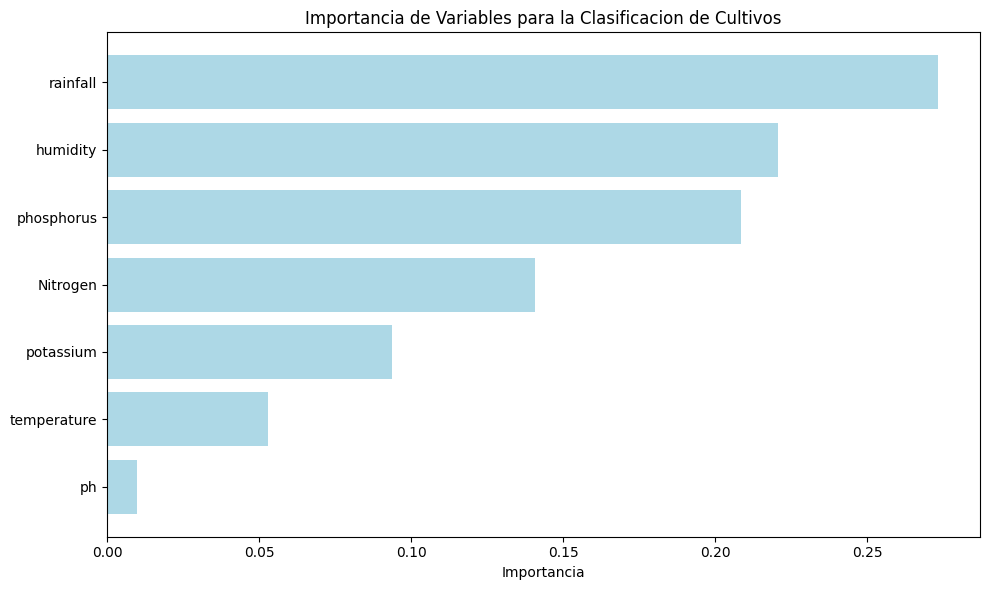


RESUMEN EJECUTIVO - PROYECTO CLASIFICACION DE CULTIVOS
MODELO ENTRENADO EXITOSAMENTE
   Accuracy: 98.8%
   Cultivos clasificados: 22
   Mejores parametros: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 15}

RENDIMIENTO POR CATEGORIA:
   Cultivos con precision perfecta: 14/22
   Cultivos con precision excelente (>=95%): 21/22
   Cultivos con precision buena (>=85%): 22/22

VARIABLES MAS IMPORTANTES:
   1. rainfall: 27.4%
   2. humidity: 22.1%
   3. phosphorus: 20.9%


In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

modelo_filename = 'modelo_clasificacion_cultivos.pkl'
joblib.dump(best_model, modelo_filename)
print(f"MODELO GUARDADO: {modelo_filename}")

# 13. CREAR FUNCION DE PREDICCION PARA NUEVOS DATOS
def recomendar_cultivo(nitrogen, phosphorus, potassium, temperature, humidity, ph, rainfall):
    """
    Funcion para recomendar cultivo basado en condiciones ambientales
    """

    nuevos_datos = np.array([[nitrogen, phosphorus, potassium, temperature, humidity, ph, rainfall]])

    # Hacer prediccion
    cultivo_recomendado = best_model.predict(nuevos_datos)[0]
    probabilidades = best_model.predict_proba(nuevos_datos)[0]

    # Obtener la probabilidad de la clase predicha
    prob_confianza = np.max(probabilidades)

    # Obtener top 3 recomendaciones
    top_3_indices = np.argsort(probabilidades)[-3:][::-1]
    top_3_cultivos = [best_model.classes_[i] for i in top_3_indices]
    top_3_probs = [probabilidades[i] for i in top_3_indices]

    print(f"RECOMENDACION DE CULTIVO:")
    print(f"   Cultivo principal: {cultivo_recomendado} (Confianza: {prob_confianza:.1%})")
    print(f"   Alternativas:")
    for i, (cultivo, prob) in enumerate(zip(top_3_cultivos[1:], top_3_probs[1:])):
        print(f"   {i+1}. {cultivo} ({prob:.1%})")

    return cultivo_recomendado

# PROBAR LA FUNCION CON EJEMPLOS
print("\n" + "="*60)
print("PRUEBA DEL MODELO CON DATOS DE EJEMPLO")
print("="*60)


# ANALISIS DE IMPORTANCIA DE CARACTERISTICAS
print("\n" + "="*60)
print("ANALISIS DE IMPORTANCIA DE VARIABLES")
print("="*60)

importancias = best_model.feature_importances_
caracteristicas = X.columns

# Crear DataFrame con importancias
df_importancias = pd.DataFrame({
    'Caracteristica': caracteristicas,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

print("\nIMPORTANCIA DE CADA VARIABLE:")
print(df_importancias.to_string(index=False))

# Grafica de importancia
plt.figure(figsize=(10, 6))
plt.barh(df_importancias['Caracteristica'], df_importancias['Importancia'], color='lightblue')
plt.xlabel('Importancia')
plt.title('Importancia de Variables para la Clasificacion de Cultivos')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# RESUMEN EJECUTIVO DEL PROYECTO
print("\n" + "="*70)
print("RESUMEN EJECUTIVO - PROYECTO CLASIFICACION DE CULTIVOS")
print("="*70)

print(f"MODELO ENTRENADO EXITOSAMENTE")
print(f"   Accuracy: {accuracy_score(y_true, y_pred):.1%}")
print(f"   Cultivos clasificados: {len(classes)}")
print(f"   Mejores parametros: {grid_search.best_params_}")

print(f"\nRENDIMIENTO POR CATEGORIA:")
cultivos_perfectos = sum(1 for p in precision_por_clase if p == 1.0)
cultivos_excelentes = sum(1 for p in precision_por_clase if p >= 0.95)
cultivos_buenos = sum(1 for p in precision_por_clase if p >= 0.85)

print(f"   Cultivos con precision perfecta: {cultivos_perfectos}/{len(classes)}")
print(f"   Cultivos con precision excelente (>=95%): {cultivos_excelentes}/{len(classes)}")
print(f"   Cultivos con precision buena (>=85%): {cultivos_buenos}/{len(classes)}")

print(f"\nVARIABLES MAS IMPORTANTES:")
top_3_vars = df_importancias.head(3)
for i, (_, row) in enumerate(top_3_vars.iterrows()):
    print(f"   {i+1}. {row['Caracteristica']}: {row['Importancia']:.1%}")



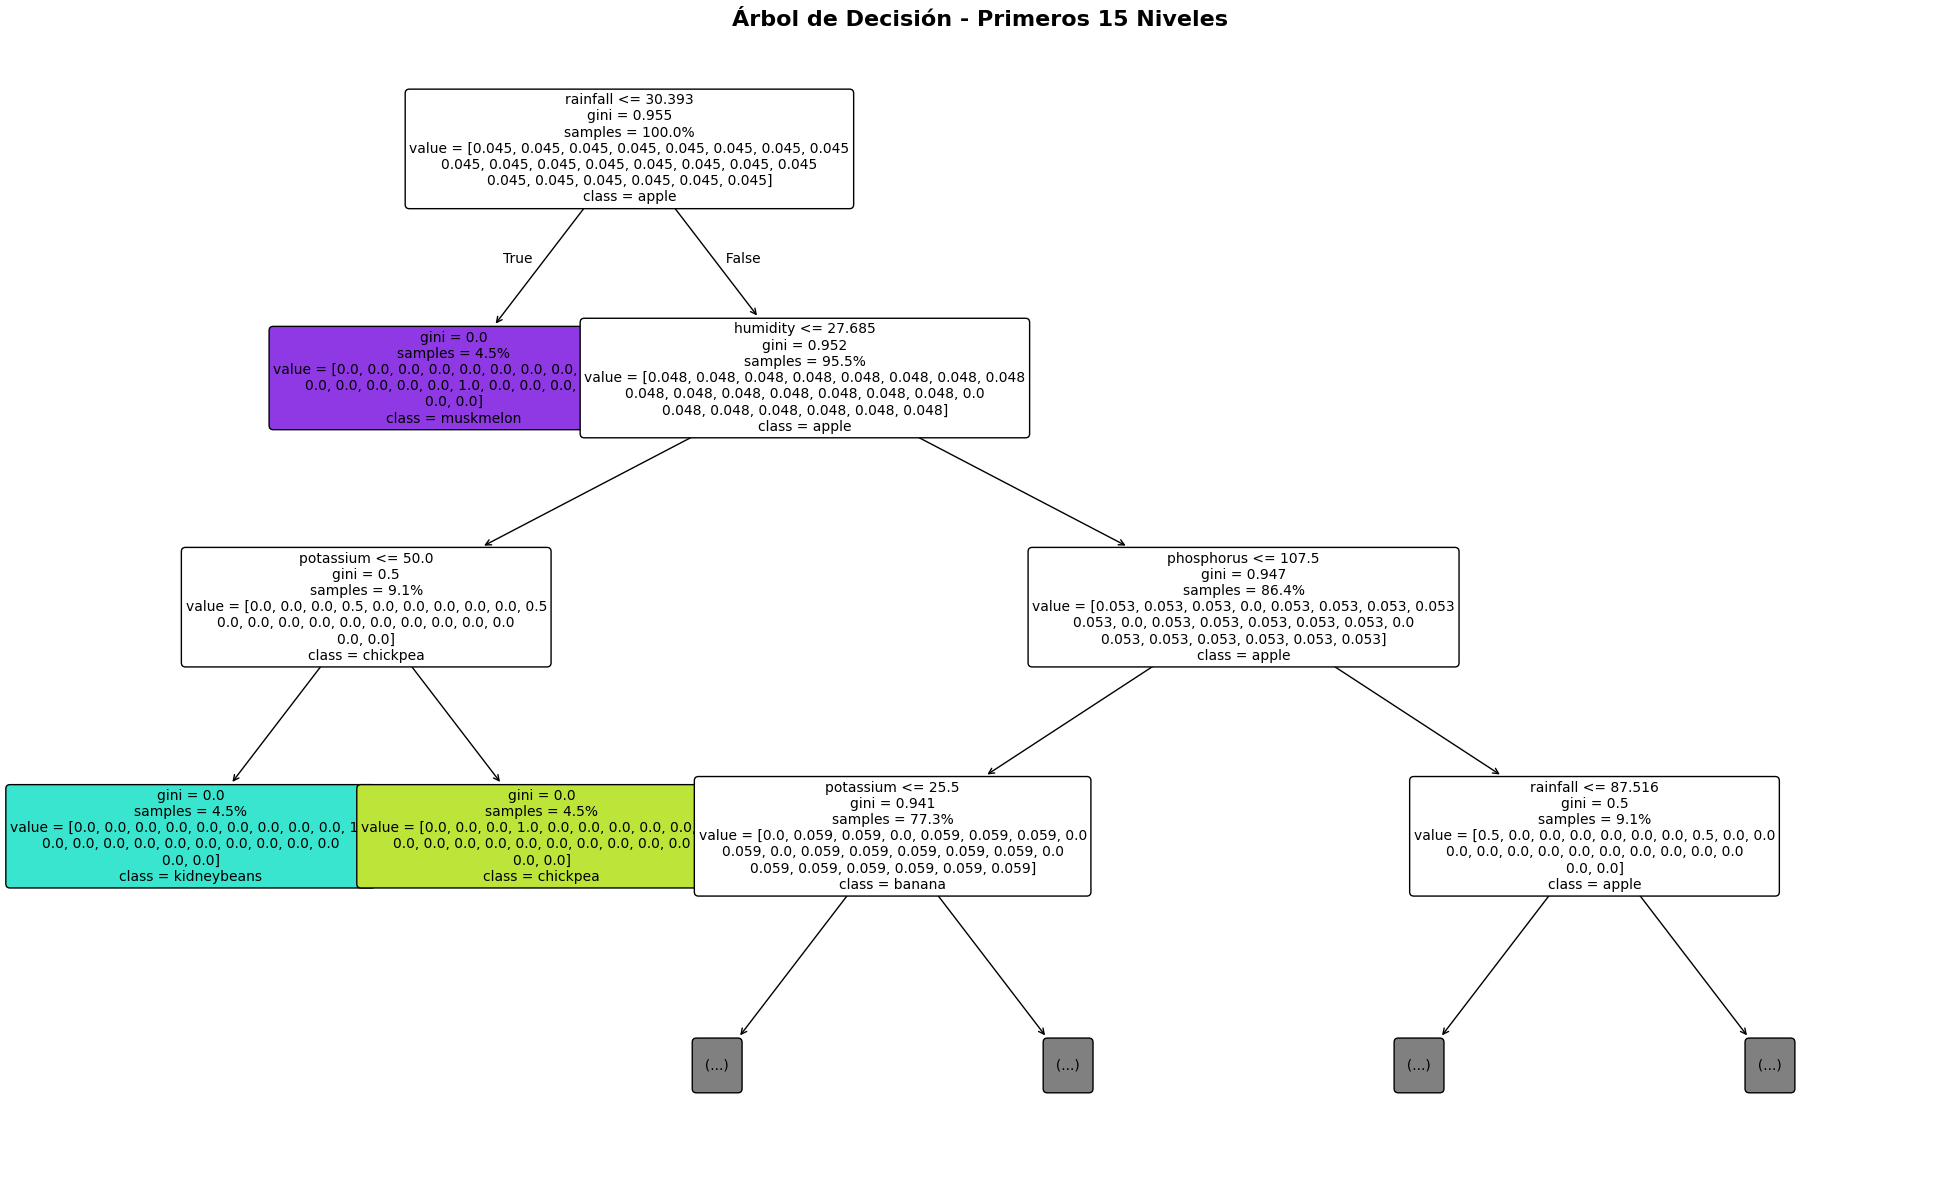

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Crear figura más grande
plt.figure(figsize=(20, 12))

# Graficar solo los primeros 3 niveles del árbol para que sea legible
plot_tree(best_model,
          feature_names=X.columns,
          class_names=[str(c) for c in best_model.classes_],
          filled=True,
          rounded=True,
          max_depth=3,  # ← Solo primeros 3 niveles
          fontsize=10,
          proportion=True)

plt.title("Árbol de Decisión - Primeros 15 Niveles", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


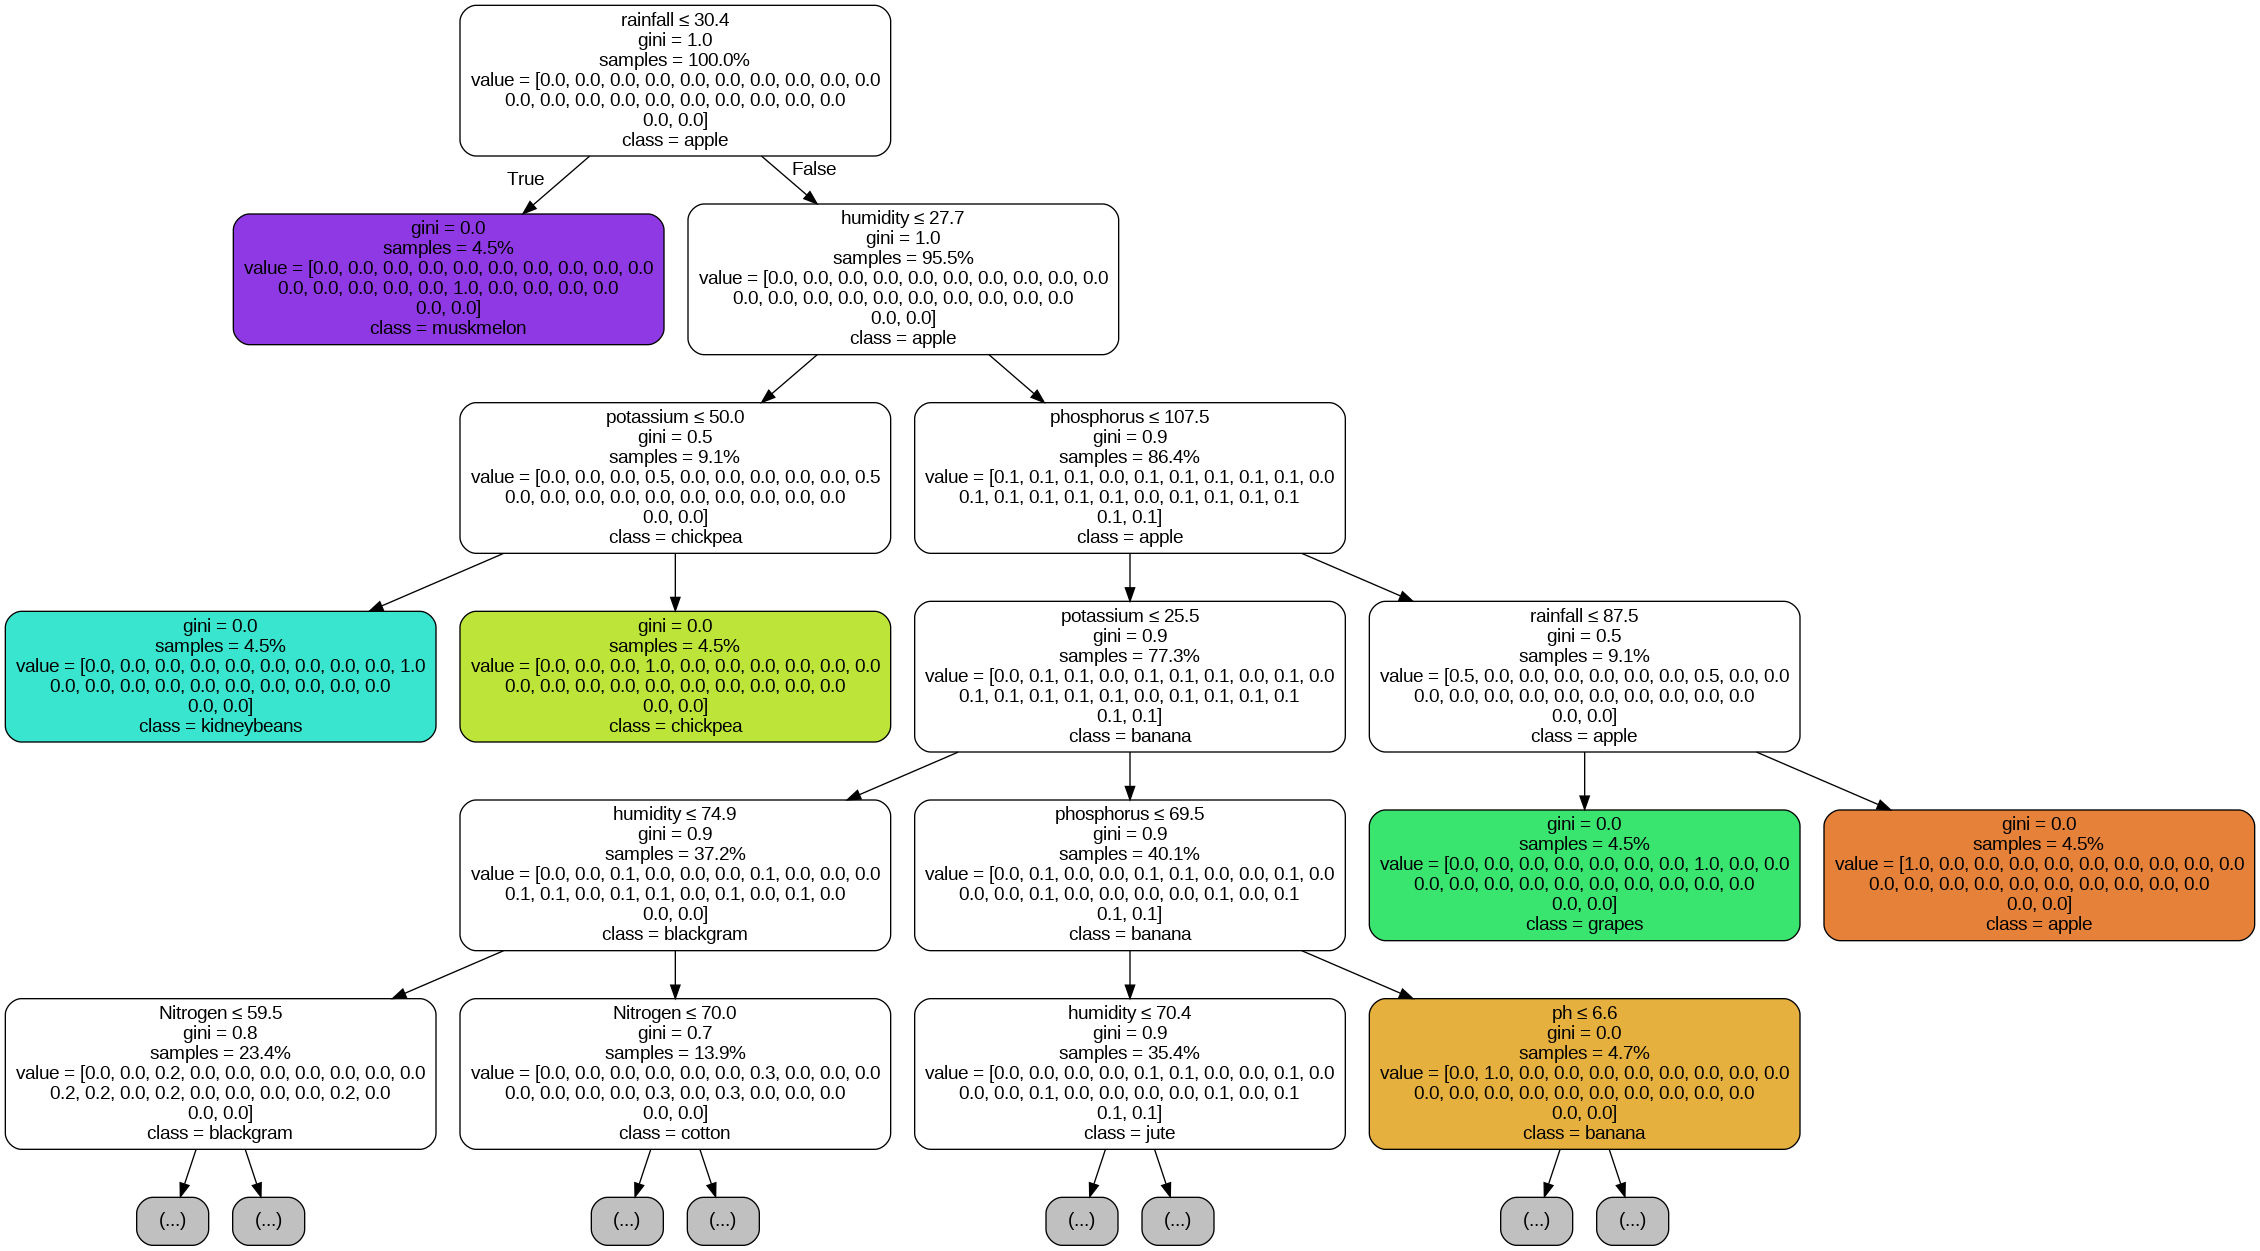

In [ ]:
# INSTALAR GRAPHVIZ PRIMERO (solo una vez)
!apt-get install graphviz -y
!pip install graphviz

import graphviz
from sklearn.tree import export_graphviz
from IPython.display import Image

# Crear el árbol con menos profundidad para que sea legible
dot_data = export_graphviz(best_model,
                          out_file=None,
                          feature_names=list(X.columns),
                          class_names=[str(c) for c in best_model.classes_],
                          filled=True,
                          rounded=True,
                          special_characters=True,
                          max_depth=5,  # Solo 3 niveles
                          proportion=True,
                          precision=1)  # Menos decimales

# Crear y mostrar el gráfico
graph = graphviz.Source(dot_data, format='png')

# Guardar y mostrar
graph_path = '/content/arbol_decision.png'
graph.render('/content/arbol_decision', cleanup=True, format='png')

# Mostrar la imagen en Colab
from IPython.display import Image
Image(filename=graph_path, width=1000)

In [ ]:
# ANALISIS DE SOBREAJUSTE
print("=== ANALISIS DE SOBREAJUSTE ===")

# DIFERENCIA ENTRE ENTRENAMIENTO Y VALIDACION
train_score = grid_search.cv_results_['mean_train_score'][grid_search.best_index_]
test_score = grid_search.cv_results_['mean_test_score'][grid_search.best_index_]
diferencia = train_score - test_score

print(f"Accuracy Entrenamiento: {train_score:.4f}")
print(f"Accuracy Validacion: {test_score:.4f}")
print(f"Diferencia: {diferencia:.4f}")

if diferencia < 0.02:
    print("ESTADO: Buen balance, poco sobreajuste")
elif diferencia < 0.05:
    print("ESTADO: Sobreajuste leve")
elif diferencia < 0.1:
    print("ESTADO: Sobreajuste moderado")
else:
    print("ESTADO: SOBREAJUSTE SEVERO")

# VERIFICAR SI HAY PERFECCIÓN EN TODOS LOS CULTIVOS
precision_por_clase = precision_score(y_true, y_pred, average=None, labels=classes)
cultivos_perfectos = sum(1 for p in precision_por_clase if p == 1.0)

print(f"\nCultivos con precision perfecta (1.000): {cultivos_perfectos}/{len(classes)}")

if cultivos_perfectos > len(classes) * 0.8:  # Más del 80% perfectos
    print("ALERTA: Demasiados cultivos con precision perfecta - posible sobreajuste")

=== ANALISIS DE SOBREAJUSTE ===
Accuracy Entrenamiento: 0.9964
Accuracy Validacion: 0.9882
Diferencia: 0.0082
ESTADO: Buen balance, poco sobreajuste

Cultivos con precision perfecta (1.000): 14/22


In [ ]:
df_rice = df[df['cultivo'] == 'rice']
df_rice_numeric = df_rice.select_dtypes(include=[np.number])  # Solo columnas numéricas
print("\n=== DATASET ARROZ ===")
df_rice_numeric.head()
# ANALIZAR LAS CARACTERÍSTICAS DEL ARROZ
print("\n=== ESTADÍSTICAS DEL ARROZ ===")
rice_stats = df_rice_numeric.describe()
print(rice_stats)

# CREAR NUEVOS DATOS SIMILARES AL ARROZ
print("\n=== CREANDO NUEVOS DATOS DE ARROZ ===")

# Obtener medias y desviaciones estándar para generar datos similares
means = df_rice_numeric.mean()
stds = df_rice_numeric.std()

# Crear 10 nuevos registros similares al arroz
np.random.seed(42)  # Para reproducibilidad
nuevos_datos_rice = []

for i in range(10):
    nuevo_registro = {}
    for col in df_rice_numeric.columns:
        if col != 'cultivo':  # No incluir la columna objetivo
            # Generar valor dentro de ±1.5 desviaciones estándar de la media
            nuevo_valor = np.random.normal(means[col], stds[col] * 0.5)
            nuevo_registro[col] = max(0, nuevo_valor)  # Evitar valores negativos

    nuevos_datos_rice.append(nuevo_registro)

# Convertir a DataFrame
df_nuevo_rice = pd.DataFrame(nuevos_datos_rice)
df_nuevo_rice['cultivo'] = 'rice'  # Asignar la etiqueta correcta

print("Nuevos datos creados base RICE:")
print(df_nuevo_rice.head(10))



=== DATASET ARROZ ===

=== ESTADÍSTICAS DEL ARROZ ===
         Nitrogen  phosphorus   potassium  temperature    humidity  \
count  100.000000  100.000000  100.000000   100.000000  100.000000   
mean    79.890000   47.580000   39.870000    23.689332   82.272822   
std     11.917981    7.904966    2.946167     2.031272    1.418381   
min     60.000000   35.000000   35.000000    20.045414   80.122675   
25%     69.000000   41.000000   38.000000    21.927064   80.952094   
50%     80.000000   47.000000   40.000000    23.734837   82.189357   
75%     91.000000   54.250000   42.000000    25.513702   83.470254   
max     99.000000   60.000000   45.000000    26.929951   84.969072   

               ph    rainfall  
count  100.000000  100.000000  
mean     6.425471  236.181114  
std      0.768692   34.291825  
min      5.005307  182.561632  
25%      5.869992  204.334023  
50%      6.363804  233.119859  
75%      7.039147  264.126903  
max      7.868475  298.560117  

=== CREANDO NUEVOS DATOS 

In [ ]:
print("=== DATOS ORIGINALES DE ARROZ ===")
df_rice = df[df['cultivo'] == 'rice']
df_rice_numeric = df_rice.select_dtypes(include=[np.number])

print(f"Registros de arroz originales: {len(df_rice)}")
print("Columnas numéricas:")
print(df_rice_numeric.head())

print("\n=== ESTADÍSTICAS DEL ARROZ ===")
rice_stats = df_rice_numeric.describe()
print(rice_stats)

print("\n=== CREANDO NUEVOS DATOS DE ARROZ ===")

means = df_rice_numeric.mean()
stds = df_rice_numeric.std()

np.random.seed(42)
nuevos_datos_rice = []

for i in range(10):
    nuevo_registro = {}
    for col in df_rice_numeric.columns:
        nuevo_valor = np.random.normal(means[col], stds[col] * 0.5)
        nuevo_registro[col] = max(0, nuevo_valor)
    nuevos_datos_rice.append(nuevo_registro)

# Convertir a DataFrame
df_nuevo_rice = pd.DataFrame(nuevos_datos_rice)
df_nuevo_rice['cultivo'] = 'rice'

print("Nuevos datos creados:")
print(df_nuevo_rice.head(10))



=== DATOS ORIGINALES DE ARROZ ===
Registros de arroz originales: 100
Columnas numéricas:
   Nitrogen  phosphorus  potassium  temperature   humidity        ph  \
0        90          42         43    20.879744  82.002744  6.502985   
1        85          58         41    21.770462  80.319644  7.038096   
2        60          55         44    23.004459  82.320763  7.840207   
3        74          35         40    26.491096  80.158363  6.980401   
4        78          42         42    20.130175  81.604873  7.628473   

     rainfall  
0  202.935536  
1  226.655537  
2  263.964248  
3  242.864034  
4  262.717340  

=== ESTADÍSTICAS DEL ARROZ ===
         Nitrogen  phosphorus   potassium  temperature    humidity  \
count  100.000000  100.000000  100.000000   100.000000  100.000000   
mean    79.890000   47.580000   39.870000    23.689332   82.272822   
std     11.917981    7.904966    2.946167     2.031272    1.418381   
min     60.000000   35.000000   35.000000    20.045414   80.122675   


Precisión en nuevos datos: 100.0%
Aciertos: 10/10

=== RESULTADOS DETALLADOS ===
   Real Predicción  Correcto
0  rice       rice      True
1  rice       rice      True
2  rice       rice      True
3  rice       rice      True
4  rice       rice      True
5  rice       rice      True
6  rice       rice      True
7  rice       rice      True
8  rice       rice      True
9  rice       rice      True

=== ANÁLISIS DE CONFIANZA ===
Muestra 1: Predice 'rice' (Confianza: 100.0%) - CORRECTO
Muestra 2: Predice 'rice' (Confianza: 100.0%) - CORRECTO
Muestra 3: Predice 'rice' (Confianza: 100.0%) - CORRECTO
Muestra 4: Predice 'rice' (Confianza: 100.0%) - CORRECTO
Muestra 5: Predice 'rice' (Confianza: 100.0%) - CORRECTO

=== COMPARACIÓN CON DATOS ORIGINALES ===
Características promedio - Original vs Nuevo:
               Original       Nuevo
Nitrogen      79.890000   76.063053
phosphorus    47.580000   47.319518
potassium     39.870000   39.283005
temperature   23.689332   23.776711
humidity      82

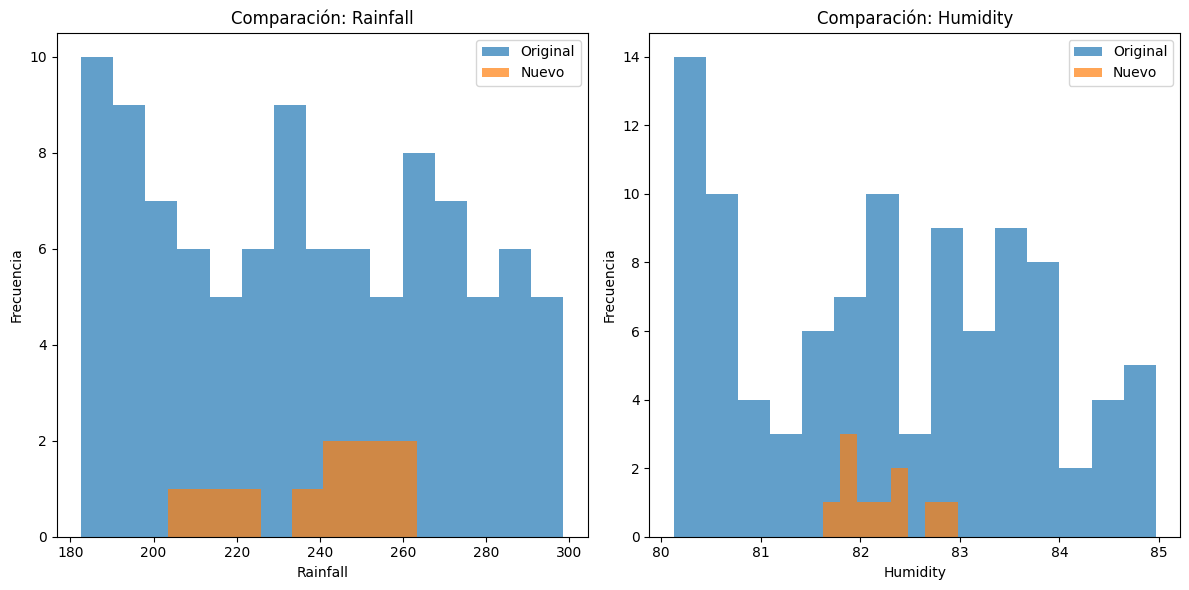


Precisión en datos originales: 98.8%
Precisión en nuevos datos: 100.0%


In [ ]:
X_nuevo = df_nuevo_rice.drop('cultivo', axis=1)
y_nuevo_real = df_nuevo_rice['cultivo']

# Hacer predicciones
y_nuevo_pred = best_model.predict(X_nuevo)

# Calcular precisión
precision_nuevos = accuracy_score(y_nuevo_real, y_nuevo_pred)
print(f"Precisión en nuevos datos: {precision_nuevos:.1%}")
print(f"Aciertos: {sum(y_nuevo_real == y_nuevo_pred)}/10")

# MOSTRAR RESULTADOS DETALLADOS
print("\n=== RESULTADOS DETALLADOS ===")
resultados = pd.DataFrame({
    'Real': y_nuevo_real,
    'Predicción': y_nuevo_pred,
    'Correcto': y_nuevo_real == y_nuevo_pred
})

print(resultados)

# ANÁLISIS DE CONFIANZA
print("\n=== ANÁLISIS DE CONFIANZA ===")
probabilidades = best_model.predict_proba(X_nuevo)

for i in range(min(5, len(df_nuevo_rice))):  # Mostrar primeros 5
    prob_max = np.max(probabilidades[i])
    clase_pred = y_nuevo_pred[i]
    correcto = "CORRECTO" if y_nuevo_real[i] == y_nuevo_pred[i] else "ERROR"

    print(f"Muestra {i+1}: Predice '{clase_pred}' (Confianza: {prob_max:.1%}) - {correcto}")

# COMPARAR CON DATOS ORIGINALES
print("\n=== COMPARACIÓN CON DATOS ORIGINALES ===")
print("Características promedio - Original vs Nuevo:")
comparacion = pd.DataFrame({
    'Original': means,
    'Nuevo': df_nuevo_rice[df_rice_numeric.columns].mean()
})
print(comparacion)

# GRÁFICA DE COMPARACIÓN
plt.figure(figsize=(12, 6))

# Comparar distribuciones de la variable más importante
plt.subplot(1, 2, 1)
plt.hist(df_rice_numeric['rainfall'], alpha=0.7, label='Original', bins=15)
plt.hist(df_nuevo_rice['rainfall'], alpha=0.7, label='Nuevo', bins=8)
plt.xlabel('Rainfall')
plt.ylabel('Frecuencia')
plt.title('Comparación: Rainfall')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_rice_numeric['humidity'], alpha=0.7, label='Original', bins=15)
plt.hist(df_nuevo_rice['humidity'], alpha=0.7, label='Nuevo', bins=8)
plt.xlabel('Humidity')
plt.ylabel('Frecuencia')
plt.title('Comparación: Humidity')
plt.legend()

plt.tight_layout()
plt.show()

# CONCLUSIÓN
print(f"\nPrecisión en datos originales: {grid_search.best_score_:.1%}")
print(f"Precisión en nuevos datos: {precision_nuevos:.1%}")

In [ ]:
print("=== DATOS ORIGINALES DE mango ===")
df_mango = df[df['cultivo'] == 'mango']
df_mango_numeric = df_mango.select_dtypes(include=[np.number])

print(f"Registros de mango originales: {len(df_mango)}")
print("Columnas numéricas:")
print(df_mango_numeric.head())

print("\n=== ESTADÍSTICAS DEL mango ===")
mango_stats = df_mango_numeric.describe()
print(mango_stats)

print("\n=== CREANDO NUEVOS DATOS DE mango ===")

means = df_mango_numeric.mean()
stds = df_mango_numeric.std()

np.random.seed(42)
nuevos_datos_mango = []

for i in range(25):
    nuevo_registro = {}
    for col in df_mango_numeric.columns:
        nuevo_valor = np.random.normal(means[col], stds[col] * 0.5)
        nuevo_registro[col] = max(0, nuevo_valor)
    nuevos_datos_mango.append(nuevo_registro)

# Convertir a DataFrame
df_nuevo_mango = pd.DataFrame(nuevos_datos_mango)
df_nuevo_mango['cultivo'] = 'mango'

print("Nuevos datos creados:")
print(df_nuevo_mango.head(10))



=== DATOS ORIGINALES DE mango ===
Registros de mango originales: 100
Columnas numéricas:
      Nitrogen  phosphorus  potassium  temperature   humidity        ph  \
1100         2          40         27    29.737700  47.548852  5.954627   
1101        39          24         31    33.556956  53.729798  4.757115   
1102        21          26         27    27.003155  47.675254  5.699587   
1103        25          22         25    33.561502  45.535566  5.977414   
1104         0          21         32    35.898556  54.259642  6.430139   

       rainfall  
1100  90.095869  
1101  98.675276  
1102  95.851183  
1103  95.705259  
1104  92.197217  

=== ESTADÍSTICAS DEL mango ===
         Nitrogen  phosphorus   potassium  temperature    humidity  \
count  100.000000  100.000000  100.000000   100.000000  100.000000   
mean    20.070000   27.180000   29.920000    31.208770   50.156573   
std     12.329037    7.663873    3.096691     2.653858    2.756285   
min      0.000000   15.000000   25.00000

Precisión en nuevos datos: 100.0%
Aciertos: 25/25

=== RESULTADOS DETALLADOS ===
     Real Predicción  Correcto
0   mango      mango      True
1   mango      mango      True
2   mango      mango      True
3   mango      mango      True
4   mango      mango      True
5   mango      mango      True
6   mango      mango      True
7   mango      mango      True
8   mango      mango      True
9   mango      mango      True
10  mango      mango      True
11  mango      mango      True
12  mango      mango      True
13  mango      mango      True
14  mango      mango      True
15  mango      mango      True
16  mango      mango      True
17  mango      mango      True
18  mango      mango      True
19  mango      mango      True
20  mango      mango      True
21  mango      mango      True
22  mango      mango      True
23  mango      mango      True
24  mango      mango      True

=== ANÁLISIS DE CONFIANZA ===
Muestra 1: Predice 'mango' (Confianza: 100.0%) - CORRECTO
Muestra 2: Predice 'mang

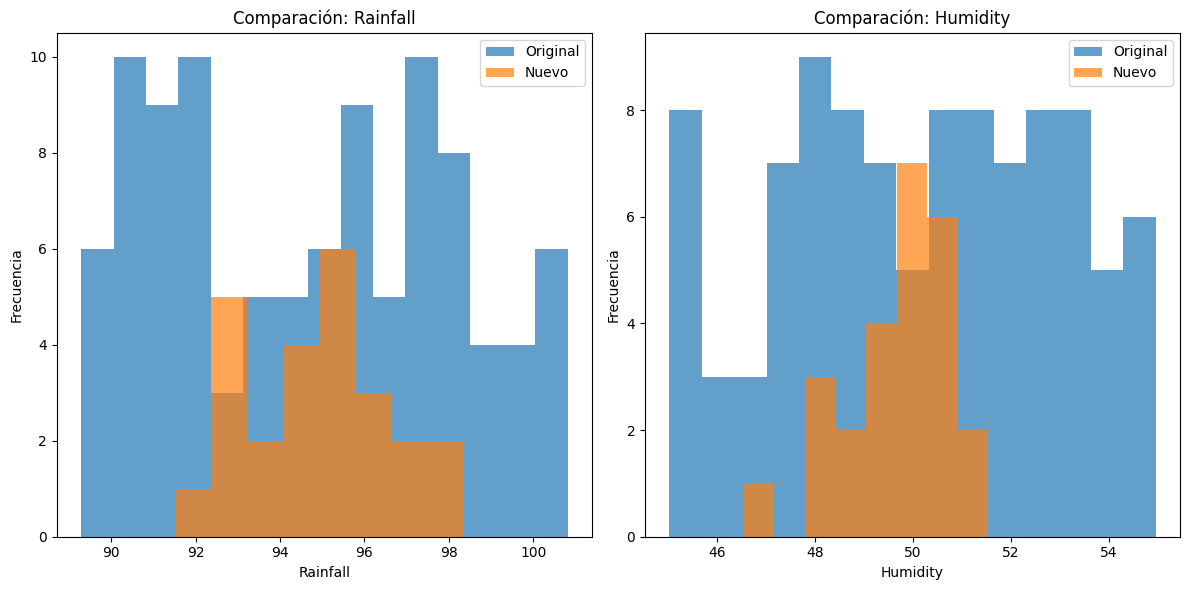


Precisión en datos originales: 98.8%
Precisión en nuevos datos: 100.0%


In [ ]:
X_nuevo = df_nuevo_mango.drop('cultivo', axis=1)
y_nuevo_real = df_nuevo_mango['cultivo']

# Hacer predicciones
y_nuevo_pred = best_model.predict(X_nuevo)
# Calcular precisión
precision_nuevos = accuracy_score(y_nuevo_real, y_nuevo_pred)
print(f"Precisión en nuevos datos: {precision_nuevos:.1%}")
print(f"Aciertos: {sum(y_nuevo_real == y_nuevo_pred)}/{len(df_nuevo_mango)}")

# 5. MOSTRAR RESULTADOS DETALLADOS
print("\n=== RESULTADOS DETALLADOS ===")
resultados = pd.DataFrame({
    'Real': y_nuevo_real,
    'Predicción': y_nuevo_pred,
    'Correcto': y_nuevo_real == y_nuevo_pred
})

print(resultados)

# 6. ANÁLISIS DE CONFIANZA
print("\n=== ANÁLISIS DE CONFIANZA ===")
probabilidades = best_model.predict_proba(X_nuevo)

for i in range(min(10, len(df_nuevo_mango))):  # Mostrar primeros 5
    prob_max = np.max(probabilidades[i])
    clase_pred = y_nuevo_pred[i]
    correcto = "CORRECTO" if y_nuevo_real[i] == y_nuevo_pred[i] else "ERROR"

    print(f"Muestra {i+1}: Predice '{clase_pred}' (Confianza: {prob_max:.1%}) - {correcto}")

# 7. COMPARAR CON DATOS ORIGINALES
print("\n=== COMPARACIÓN CON DATOS ORIGINALES ===")
print("Características promedio - Original vs Nuevo:")
comparacion = pd.DataFrame({
    'Original': means,
    'Nuevo': df_nuevo_mango[df_mango_numeric.columns].mean()
})
print(comparacion)

# GRÁFICA DE COMPARACIÓN
plt.figure(figsize=(12, 6))

# Comparar distribuciones de la variable más importante
plt.subplot(1, 2, 1)
plt.hist(df_mango_numeric['rainfall'], alpha=0.7, label='Original', bins=15)
plt.hist(df_nuevo_mango['rainfall'], alpha=0.7, label='Nuevo', bins=8)
plt.xlabel('Rainfall')
plt.ylabel('Frecuencia')
plt.title('Comparación: Rainfall')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df_mango_numeric['humidity'], alpha=0.7, label='Original', bins=15)
plt.hist(df_nuevo_mango['humidity'], alpha=0.7, label='Nuevo', bins=8)
plt.xlabel('Humidity')
plt.ylabel('Frecuencia')
plt.title('Comparación: Humidity')
plt.legend()

plt.tight_layout()
plt.show()

# CONCLUSIÓN
print(f"\nPrecisión en datos originales: {grid_search.best_score_:.1%}")
print(f"Precisión en nuevos datos: {precision_nuevos:.1%}")